# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** _(George Albadr)_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [1]:
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [2]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala"
    # ¿Qué va aquí? latitude, longitude, start_date, end_date,
    # daily (dos variables separadas por coma), timezone
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [3]:
clima = pd.DataFrame(datos["daily"])   # ¿Qué va aquí?

# convertir time a datetime
clima["time"] = pd.to_datetime(clima["time"])

clima.head()  #(descomentar al llenar)

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [4]:
# hacer una columna booleana lluvia, que sea True si la precipitación es mayor a 1.0 y False en caso contrario.

clima["llovio"] = clima["precipitation_sum"] > 1.0

k = clima["llovio"].sum()
n = len(clima)

dia_max = clima.loc[clima["precipitation_sum"].idxmax()]

print(f"De {n} días, llovió en {k} días ({k/n:.1%})")
print(f"El día con más lluvia fue {dia_max['time'].date()} con {dia_max['precipitation_sum']} mm")
# Verificación (descomentar):
assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

De 92 días, llovió en 51 días (55.4%)
El día con más lluvia fue 2026-06-22 con 27.7 mm


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [5]:
from datetime import date

ficha = {
    "fuente": "Open-Meteo",
    "url": URL,
    "rango_fechas": [str(clima["time"].min().date()), str(clima["time"].max().date())],
    "fecha_descarga": date.today().isoformat(),
    "filas": len(clima),
    "variables": params["daily"].split(","),
}

# guardar ficha como clima_procedencia.json y clima como clima_gt.csv
with open("clima_procedencia.json", "w") as f:
    json.dump(ficha, f, indent=4, ensure_ascii=False)

clima.to_csv("clima_gt.csv", index=False)

print(ficha)

# Verificación (descomentar):
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

{'fuente': 'Open-Meteo', 'url': 'https://archive-api.open-meteo.com/v1/archive', 'rango_fechas': ['2026-05-01', '2026-07-31'], 'fecha_descarga': '2026-08-13', 'filas': 92, 'variables': ['temperature_2m_max', 'precipitation_sum']}


## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [6]:
p_hat = k / n    # ¿Qué va aquí? el MLE en una línea

def log_lik(p, k, n):
    # ¿Qué va aquí?
    return k * np.log(p) + (n - k) * np.log(1 - p)

grilla = np.linspace(0.001, 0.999, 999)
p_grilla = grilla[np.argmax(log_lik(grilla, k, n))]   # ¿Qué va aquí? argmax sobre la grilla

# Verificación (descomentar):
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

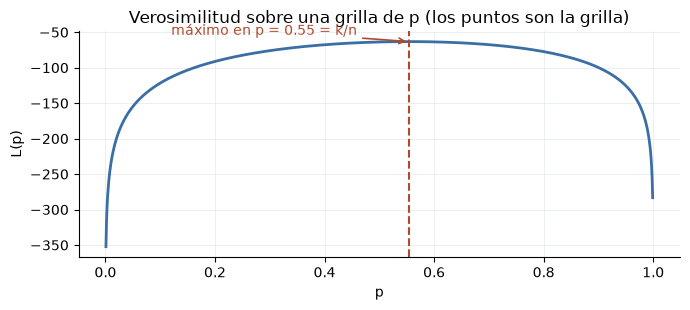

In [7]:
# ¿Qué va aquí?
values = log_lik(grilla, k, n)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(grilla, values, color=AZUL, lw=2)
ax.axvline(p_hat, color=ROJO, ls="--", lw=1.5)
ax.annotate(f"máximo en p = {p_hat:.2f} = k/n",
            xy=(p_hat, values.max()), 
            xytext=(0.12, values.max() * 0.85),
            color=ROJO,
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2))
ax.set_xlabel("p")
ax.set_ylabel("L(p)")
ax.set_title("Verosimilitud sobre una grilla de p (los puntos son la grilla)")
eje_limpio(ax)
plt.tight_layout()
plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [8]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = temp.sum() / len(temp)

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = ((temp - mu_hat)**2).sum() / len(temp)

print(f"mu_hat     = {mu_hat:.4f}  (numpy: {temp.mean():.4f})")
print(f"sigma2_hat = {sigma2_hat:.4f}")
print(f"sigma_hat  = {np.sqrt(sigma2_hat):.4f}  (numpy: {temp.std(ddof=0):.4f})")

# Verificación (descomentar):
assert np.isclose(mu_hat, temp.mean())
assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

mu_hat     = 26.8598  (numpy: 26.8598)
sigma2_hat = 3.6257
sigma_hat  = 1.9041  (numpy: 1.9041)


### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [9]:
def mle(k_demo, n_demo):
    return k_demo / n_demo

def map_beta(k, n, a=2, b=10):
    return (k + a - 1) / (n + a + b - 2)

# el prior pesa distinto segun cuantos datos haya (n_demo, MLE, MAP)
for k_demo, n_demo in [(2, 2), (20, 20), (700, 1000)]:
    print(n_demo, round(mle(k_demo, n_demo), 3), round(map_beta(k_demo, n_demo), 3))

# comparar MLE y MAP con los 92 días
print(f"\nCon los {n} días: MLE = {mle(k, n):.3f}, MAP = {map_beta(k, n):.3f}, "
      f"diferencia = {abs(mle(k, n) - map_beta(k, n)):.3f}")

# Verificación (descomentar):
assert round(map_beta(k, n), 3) == 0.510

2 1.0 0.25
20 1.0 0.7
1000 0.7 0.694

Con los 92 días: MLE = 0.554, MAP = 0.510, diferencia = 0.045


### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [10]:
ns = [7, 14, 30, 60, 92]
resultados = []

print(f"{'m':>3} {'k_m':>4} {'MLE':>7} {'MAP':>7} {'|dif|':>7}")
for m in ns:
    k_m = int(clima["llovio"][:m].sum())
    mle_m = mle(k_m, m)
    map_m = map_beta(k_m, m)
    resultados.append((m, mle_m, map_m))
    print(f"{m:>3} {k_m:>4} {mle_m:>7.3f} {map_m:>7.3f} {abs(mle_m - map_m):>7.3f}")

# Verificación (descomentar):
difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

  m  k_m     MLE     MAP   |dif|
  7    3   0.429   0.235   0.193
 14    4   0.286   0.208   0.077
 30   14   0.467   0.375   0.092
 60   38   0.633   0.557   0.076
 92   51   0.554   0.510   0.045


### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

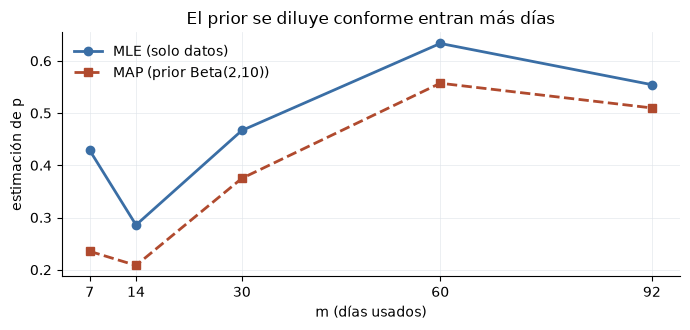

In [11]:
ms, mles, maps = zip(*resultados)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ms, mles, color=AZUL, lw=2, marker="o", label="MLE (solo datos)")
ax.plot(ms, maps, color=ROJO, lw=2, marker="s", ls="--", label="MAP (prior Beta(2,10))")
ax.set_xlabel("m (días usados)")
ax.set_ylabel("estimación de p")
ax.set_title("El prior se diluye conforme entran más días")
ax.set_xticks(ms)
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?

_(Responder editando esta celda)_

**Respuesta:** Los datos fueron diluyendo el prior hasta dejarlo casi mudo: con m=7 la diferencia entre MLE y MAP era de 0.19 (0.429 contra 0.235, o sea el prior jalaba la estimación a menos de la mitad), y con m=92 bajó a 0.045 (0.554 contra 0.510). El prior dejó de dominar alrededor de los 30 días, que es cuando los datos reales ya pesan bastante más que los 10 días imaginarios que mete Beta(2,10); de ahí en adelante las dos curvas del ejercicio 10 van casi pegadas. La implicación para ridge/lasso es la misma: la penalización funciona como un prior, así que con pocos datos manda ella y no las observaciones, y si está mal elegida sesga el modelo sin que nada truene. Por eso conviene ajustar la fuerza de la regularización (validación cruzada) justo cuando hay pocos datos, y no preocuparse tanto cuando el n es grande porque de todos modos se va a diluir.

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Fuentes: https://medium.com/data-bistrot/bernoulli-distribution-with-python-0416e196e752

**Mini-bitácora de AI (Claude):**

- Ejercicio 3: Se preguntó para qué sirven `k` y `n` sobre la columna booleana `llovio`. Se entendió que la columna convierte cada día en un ensayo Bernoulli, y que `k` y `n` son estadísticos suficientes: toda la Parte B (MLE, log-verosimilitud, MAP) se calcula solo con esos dos números, sin volver a tocar el DataFrame.

- Ejercicio 5: Se preguntó por qué la log-verosimilitud usa el log y por qué mi versión con `np.array([k, n-k])` fallaba al pasarle la grilla. Se entendió que el log convierte el producto `p^k (1-p)^(n-k)` en una suma y evita el underflow, y que escribir la fórmula directa `k*np.log(p) + (n-k)*np.log(1-p)` ya queda vectorizada porque `k` y `n` son escalares y se difunden sobre el arreglo de `p`.

- Ejercicios 8 y 9: Se preguntó por qué el assert fallaba si la fórmula del MAP estaba bien. Se entendió que usar `k` y `n` como variables de un `for` las sobreescribe globalmente (quedaban en 700 y 1000), y que el error no lanza excepción sino que contamina las celdas de abajo; también que en el ejercicio 9 el tamaño de muestra es `m` y no `n`, y que hay que reusar `map_beta` en vez de re-escribir la fórmula con otro prior.

- Ejercicios 10 y 11: Se pidió ayuda para corregir el gráfico.